In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
activity = pd.read_csv('dailyActivity_merged.csv')
sleep = pd.read_csv('sleepDay_merged.csv')
hourly_steps = pd.read_csv('hourlySteps_merged.csv')

# Quick check
print("Activity shape:", activity.shape)
print("Sleep shape:", sleep.shape)
print("Hourly steps shape:", hourly_steps.shape)

Activity shape: (940, 15)
Sleep shape: (413, 5)
Hourly steps shape: (22099, 3)


In [2]:
# See what columns we're working with
print("=== ACTIVITY COLUMNS ===")
print(activity.columns.tolist())

print("\n=== SLEEP COLUMNS ===")
print(sleep.columns.tolist())

print("\n=== FIRST FEW ROWS OF ACTIVITY ===")
activity.head()

=== ACTIVITY COLUMNS ===
['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']

=== SLEEP COLUMNS ===
['Id', 'SleepDay', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed']

=== FIRST FEW ROWS OF ACTIVITY ===


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [3]:
# Fix date columns
activity['ActivityDate'] = pd.to_datetime(activity['ActivityDate'])
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'])

# Check for nulls
print("=== NULLS ===")
print("Activity:", activity.isnull().sum().sum())
print("Sleep:", sleep.isnull().sum().sum())
print("Hourly steps:", hourly_steps.isnull().sum().sum())

# Check for duplicates
print("\n=== DUPLICATES ===")
print("Activity:", activity.duplicated().sum())
print("Sleep:", sleep.duplicated().sum())
print("Hourly steps:", hourly_steps.duplicated().sum())

# Drop duplicates if any
sleep = sleep.drop_duplicates()

# How many unique users?
print("\n=== UNIQUE USERS ===")
print("Activity:", activity['Id'].nunique())
print("Sleep:", sleep['Id'].nunique())
print("Hourly steps:", hourly_steps['Id'].nunique())

/tmp/ipykernel_1898/3588078526.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
/tmp/ipykernel_1898/3588078526.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'])


=== NULLS ===
Activity: 0
Sleep: 0
Hourly steps: 0

=== DUPLICATES ===
Activity: 0
Sleep: 3
Hourly steps: 0

=== UNIQUE USERS ===
Activity: 33
Sleep: 24
Hourly steps: 33


In [4]:
# Add a day-of-week column
activity['DayOfWeek'] = activity['ActivityDate'].dt.day_name()

# Overall stats
print("=== AVERAGE DAILY STATS ===")
print(f"Avg Steps:    {activity['TotalSteps'].mean():.0f}")
print(f"Avg Calories: {activity['Calories'].mean():.0f}")
print(f"Avg Sedentary Minutes: {activity['SedentaryMinutes'].mean():.0f} ({activity['SedentaryMinutes'].mean()/60:.1f} hrs)")
print(f"Avg Very Active Minutes: {activity['VeryActiveMinutes'].mean():.0f}")

# User activity segments
activity['UserType'] = pd.cut(
    activity.groupby('Id')['TotalSteps'].transform('mean'),
    bins=[0, 5000, 7500, 10000, float('inf')],
    labels=['Sedentary', 'Low Active', 'Fairly Active', 'Very Active']
)

print("\n=== USER SEGMENTS ===")
print(activity.groupby('UserType', observed=True)['Id'].nunique())

=== AVERAGE DAILY STATS ===
Avg Steps:    7638
Avg Calories: 2304
Avg Sedentary Minutes: 991 (16.5 hrs)
Avg Very Active Minutes: 21

=== USER SEGMENTS ===
UserType
Sedentary        8
Low Active       9
Fairly Active    9
Very Active      7
Name: Id, dtype: int64


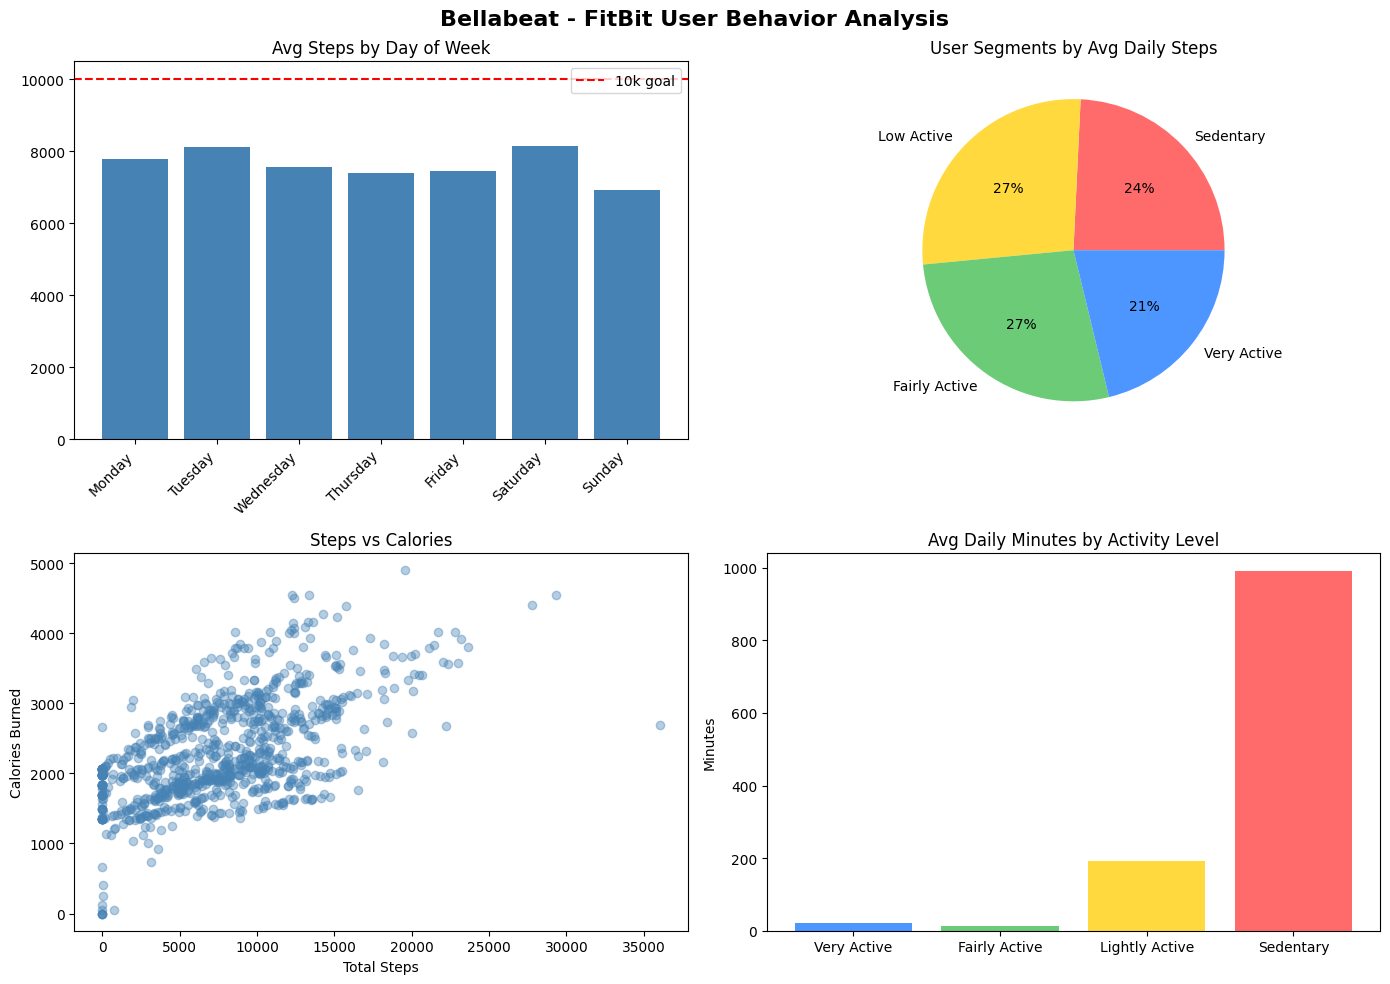

Chart saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bellabeat - FitBit User Behavior Analysis', fontsize=16, fontweight='bold')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
steps_by_day = activity.groupby('DayOfWeek')['TotalSteps'].mean().reindex(day_order)
axes[0,0].bar(steps_by_day.index, steps_by_day.values, color='steelblue')
axes[0,0].axhline(y=10000, color='red', linestyle='--', label='10k goal')
axes[0,0].set_title('Avg Steps by Day of Week')
axes[0,0].set_xticks(range(len(day_order)))
axes[0,0].set_xticklabels(day_order, rotation=45, ha='right')
axes[0,0].legend()

segment_counts = activity.groupby('UserType', observed=True)['Id'].nunique()
axes[0,1].pie(segment_counts, labels=segment_counts.index, autopct='%1.0f%%',
              colors=['#ff6b6b','#ffd93d','#6bcb77','#4d96ff'])
axes[0,1].set_title('User Segments by Avg Daily Steps')

axes[1,0].scatter(activity['TotalSteps'], activity['Calories'], alpha=0.4, color='steelblue')
axes[1,0].set_xlabel('Total Steps')
axes[1,0].set_ylabel('Calories Burned')
axes[1,0].set_title('Steps vs Calories')

avg_minutes = {
    'Very Active': activity['VeryActiveMinutes'].mean(),
    'Fairly Active': activity['FairlyActiveMinutes'].mean(),
    'Lightly Active': activity['LightlyActiveMinutes'].mean(),
    'Sedentary': activity['SedentaryMinutes'].mean()
}
axes[1,1].bar(avg_minutes.keys(), avg_minutes.values(),
              color=['#4d96ff','#6bcb77','#ffd93d','#ff6b6b'])
axes[1,1].set_title('Avg Daily Minutes by Activity Level')
axes[1,1].set_ylabel('Minutes')

plt.tight_layout()
plt.savefig('bellabeat_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

=== SLEEP STATS ===
Avg Time Asleep:     419 mins (7.0 hrs)
Avg Time in Bed:     458 mins (7.6 hrs)
Avg Awake in Bed:    39 mins
Avg Sleep Efficiency:91.6%


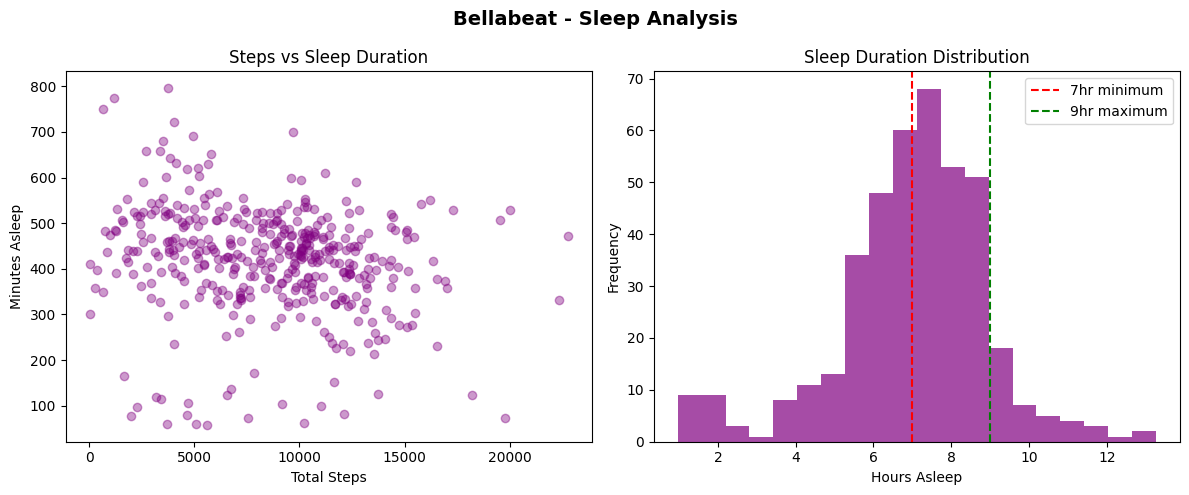


=== KEY FINDINGS FOR BELLABEAT ===
1. Users average 7,638 steps/day — below the 10,000 recommended
2. Users spend 16.5 hrs/day sedentary — major opportunity for reminders
3. Only 24/33 users track sleep — feature awareness gap
4. Avg 39 mins spent awake in bed — stress/wind-down issue
5. Tuesday & Saturday are peak activity days, Sunday is lowest


In [8]:
# Sleep analysis
sleep['MinutesAwakeInBed'] = sleep['TotalTimeInBed'] - sleep['TotalMinutesAsleep']
sleep['SleepEfficiency'] = (sleep['TotalMinutesAsleep'] / sleep['TotalTimeInBed'] * 100).round(1)

print("=== SLEEP STATS ===")
print(f"Avg Time Asleep:     {sleep['TotalMinutesAsleep'].mean():.0f} mins ({sleep['TotalMinutesAsleep'].mean()/60:.1f} hrs)")
print(f"Avg Time in Bed:     {sleep['TotalTimeInBed'].mean():.0f} mins ({sleep['TotalTimeInBed'].mean()/60:.1f} hrs)")
print(f"Avg Awake in Bed:    {sleep['MinutesAwakeInBed'].mean():.0f} mins")
print(f"Avg Sleep Efficiency:{sleep['SleepEfficiency'].mean():.1f}%")

# Sleep vs steps (merge datasets)
activity_sleep = pd.merge(activity, sleep, left_on=['Id','ActivityDate'],
                          right_on=['Id','SleepDay'], how='inner')

# Plot sleep insights
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Bellabeat - Sleep Analysis', fontsize=14, fontweight='bold')

axes[0].scatter(activity_sleep['TotalSteps'], activity_sleep['TotalMinutesAsleep'],
                alpha=0.4, color='purple')
axes[0].set_xlabel('Total Steps')
axes[0].set_ylabel('Minutes Asleep')
axes[0].set_title('Steps vs Sleep Duration')

axes[1].hist(sleep['TotalMinutesAsleep']/60, bins=20, color='purple', alpha=0.7)
axes[1].axvline(x=7, color='red', linestyle='--', label='7hr minimum')
axes[1].axvline(x=9, color='green', linestyle='--', label='9hr maximum')
axes[1].set_xlabel('Hours Asleep')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Sleep Duration Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('bellabeat_sleep.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== KEY FINDINGS FOR BELLABEAT ===")
print("1. Users average 7,638 steps/day — below the 10,000 recommended")
print("2. Users spend 16.5 hrs/day sedentary — major opportunity for reminders")
print("3. Only 24/33 users track sleep — feature awareness gap")
print(f"4. Avg {sleep['MinutesAwakeInBed'].mean():.0f} mins spent awake in bed — stress/wind-down issue")
print("5. Tuesday & Saturday are peak activity days, Sunday is lowest")

In [9]:
print("""
================================================
BELLABEAT MARKETING RECOMMENDATIONS
Based on FitBit User Behavior Analysis (n=33)
================================================

FINDING 1: Users are highly sedentary (16.5 hrs/day)
RECOMMENDATION: Bellabeat Leaf/Time should send hourly movement
reminders during peak sedentary hours. Gamify streaks for
breaking sedentary time every 60 minutes.

FINDING 2: Average steps (7,638) fall below the 10k goal
RECOMMENDATION: Bellabeat app should use adaptive daily step
goals rather than a fixed 10k — starting users at their current
average and nudging them up gradually to improve retention.

FINDING 3: Only 24 of 33 users track sleep
RECOMMENDATION: Push in-app prompts encouraging sleep tracking
setup. Market the Bellabeat Spring (water bottle) with a
hydration-sleep connection campaign since sleep quality affects
energy levels.

FINDING 4: 39 mins spent awake in bed on average
RECOMMENDATION: Introduce a "wind-down mode" in the Bellabeat
app — evening reminders to reduce screen time, guided breathing,
and a consistent bedtime notification.

FINDING 5: Activity dips on Sunday
RECOMMENDATION: Launch a "Sunday Reset" weekly challenge in the
app to boost engagement on the lowest activity day.
================================================
""")


BELLABEAT MARKETING RECOMMENDATIONS
Based on FitBit User Behavior Analysis (n=33)

FINDING 1: Users are highly sedentary (16.5 hrs/day)
RECOMMENDATION: Bellabeat Leaf/Time should send hourly movement 
reminders during peak sedentary hours. Gamify streaks for 
breaking sedentary time every 60 minutes.

FINDING 2: Average steps (7,638) fall below the 10k goal
RECOMMENDATION: Bellabeat app should use adaptive daily step 
goals rather than a fixed 10k — starting users at their current 
average and nudging them up gradually to improve retention.

FINDING 3: Only 24 of 33 users track sleep
RECOMMENDATION: Push in-app prompts encouraging sleep tracking 
setup. Market the Bellabeat Spring (water bottle) with a 
hydration-sleep connection campaign since sleep quality affects 
energy levels.

FINDING 4: 39 mins spent awake in bed on average
RECOMMENDATION: Introduce a "wind-down mode" in the Bellabeat 
app — evening reminders to reduce screen time, guided breathing, 
and a consistent bedtime no